# Import 

In [2]:
import pandas as pd
import numpy as np
import textwrap

from plotnine import (
    ggplot, aes, geom_bar, geom_label,
    scale_fill_manual, scale_x_discrete, scale_y_continuous,
    coord_flip, theme_minimal, theme, labs, guides, guide_legend,
    element_text, position_stack
)
from mizani.formatters import number_format

In [5]:
data_non_ubb = pd.DataFrame({
    "vars": ["Q1", "Q2", "Q3", "Q4"],
    "label_short": [
        "Satisfaction with price",
        "Ease of use",
        "Recommendation likelihood",
        "Customer support quality"
    ],
    "vals": ["Agree", "Neutral", "Disagree", "Agree"],
    "p": [55, 25, 10, 65],
    "anz": [110, 50, 20, 130],
    "label_n": ["n=110", "n=50", "n=20", "n=130"]
})

labels_non_ubb = {
    "labels": ["Agree", "Neutral", "Disagree"],
    "colors": ["#2E7D32", "#9E9E9E", "#C62828"]
}

data_non_ubb.head()

,vars,label_short,vals,p,anz,label_n
0,Q1,Satisfaction with price,Agree,55,110,n=110
1,Q2,Ease of use,Neutral,25,50,n=50
2,Q3,Recommendation likelihood,Disagree,10,20,n=20
3,Q4,Customer support quality,Agree,65,130,n=130


In [9]:
df = data_non_ubb.copy()
labels = labels_non_ubb.copy()

for col in ["anz", "p"]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["vals"] = pd.Categorical(
    df["vals"],
    categories=labels["labels"],
    ordered=True
)

df.head()

,vars,label_short,vals,p,anz,label_n
0,Q1,Satisfaction with price,Agree,55,110,n=110
1,Q2,Ease of use,Neutral,25,50,n=50
2,Q3,Recommendation likelihood,Disagree,10,20,n=20
3,Q4,Customer support quality,Agree,65,130,n=130


In [11]:
df["newlable"] = (
    df["vars"].astype(str)
    + ": "
    + df["label_short"].astype(str)
    )

df["newlable"] = pd.Categorical(df["newlable"])

def wrap_label(x):
    return textwrap.fill(str(x), width=45)

df["bold_labels"] = df["newlable"].astype(str).apply(wrap_label)

df["geom_label_text"] = np.where(
    df["p"] > 3,
    df["label_n"].astype(str) + "\n" + df["anz"].astype(str),
    ""
    )

reversed_levels = list(df["newlable"].cat.categories[::-1])
df.head()

,vars,label_short,vals,p,anz,label_n,newlable,bold_labels,geom_label_text
0,Q1,Satisfaction with price,Agree,55,110,n=110,Q1: Satisfaction with price,Q1: Satisfaction with price,n=110\n110
1,Q2,Ease of use,Neutral,25,50,n=50,Q2: Ease of use,Q2: Ease of use,n=50\n50
2,Q3,Recommendation likelihood,Disagree,10,20,n=20,Q3: Recommendation likelihood,Q3: Recommendation likelihood,n=20\n20
3,Q4,Customer support quality,Agree,65,130,n=130,Q4: Customer support quality,Q4: Customer support quality,n=130\n130


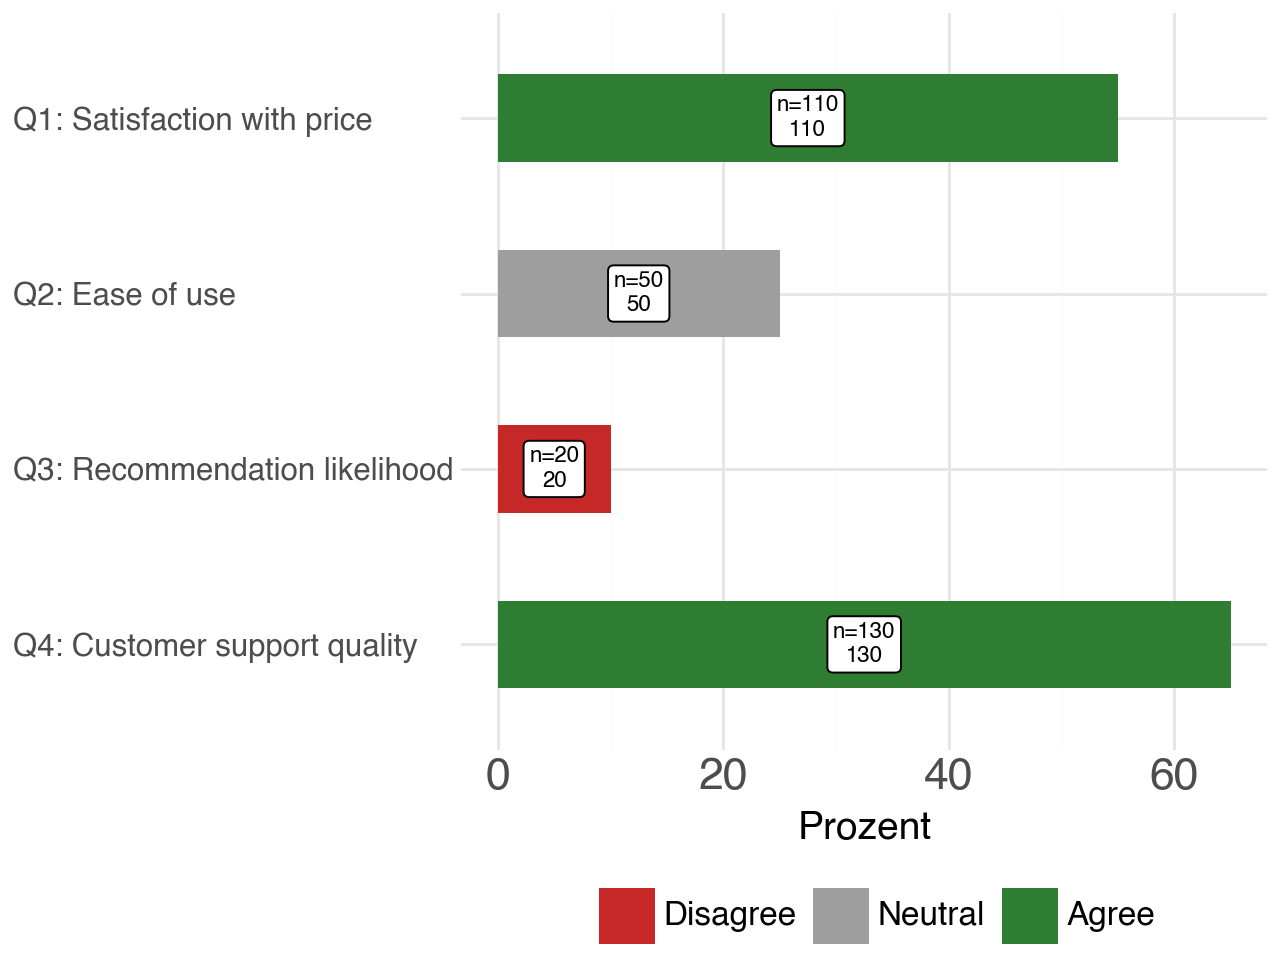

In [15]:
p = (
    ggplot(df, aes(x="newlable", y="p", fill="vals"))
    + geom_bar(
        stat="identity",
        position="stack",
        width=0.5
    )
    + geom_label(
        aes(label="geom_label_text"),
        position=position_stack(vjust=0.5),
        size=8,
        fill="white",
        color="black"
    )
    + scale_fill_manual(
        breaks=list(reversed(labels["labels"])),
        values=list(reversed(labels["colors"])),
        drop=True
    )
    + scale_x_discrete(limits=reversed_levels)
    + coord_flip()
    + scale_y_continuous(
        labels=number_format(accuracy=1)  # safe numeric scale
    )
    + theme_minimal(base_size=14)
    + theme(
        legend_position="bottom",
        legend_text=element_text(size=12, lineheight=0.8),
        axis_text_x=element_text(size=16),
        axis_text_y=element_text(ha="left")
    )
    + labs(x="", y="Prozent", fill="")
    + guides(
        fill=guide_legend(nrow=1)
    )
)

p.show()